In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    StratifiedKFold, RepeatedStratifiedKFold, cross_validate, learning_curve, train_test_split
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("../../data/feat/tweet_emotions_ptbr_with_features.csv")

df['CLEAN_TEXT'] = (
    df['CLEAN_TEXT']
    .fillna("")        # remove NaN
    .astype(str)       # garante string
)

print(df.shape)
df.head(3)

(12419, 38)


,UNCLEAN_TEXT,EMOTION,CLEAN_TEXT,letter_count,sentence_count,avg_letter_per_word,words_per_sentence,avg_syllables_per_word,reading_time,fernandez_huerta,...,sim_emotion_submissão,sim_emotion_nojo,sim_emotion_medo,sim_emotion_decepção,sim_emotion_amor,sim_emotion_remorso,sim_emotion_confianca,sim_emotion_antecipacao,sim_emotion_surpresa,sim_emotion_intimidação
0,͏ ͏ ͏ ͏ ͏ ͏ ͏ ͏\nque júbilo incalculável ver t...,alegria,que jubilo incalculavel ver todo meu querido q...,87.0,1.0,5.117647,17.0,2.000000,1.52776,69.50,...,0.257600,0.218214,0.222101,0.258962,0.273969,0.217937,0.242495,0.248363,0.222737,0.183954
1,". 𝘀𝗮𝗽𝗼𝗻𝘁𝗮𝗺𝗲𝗻𝘁𝗼𝗶\nSenhor, arranca do meu coraçã...",decepção,sapontamentoir senhor arrancar meu coracao qua...,174.0,3.0,4.461538,13.0,1.666667,2.67358,93.58,...,0.491253,0.381422,0.388554,0.460373,0.401383,0.445858,0.380126,0.313212,0.298933,0.320575
2,"A franquia continua ativa, com o desenvolvimen...",decepção,franquia continuar ativo com desenvolvimento j...,167.0,1.0,5.566667,30.0,2.366667,2.49730,34.24,...,0.051293,0.019359,0.049557,0.098947,0.040779,0.067483,0.027425,0.110073,0.102952,0.122554


In [3]:
def avaliar_cv(model, X_train, y_train, n_splits=5, n_repeats=6):
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

    # macro: trata todas as classes igualmente (classes raras importam tanto quanto classes frequentes)
    # weighted: melhor se houver desbalanceamento (penaliza menos erros em classes raras)
    scoring = {
        'accuracy': 'accuracy',
        'f1_macro': 'f1_macro',
        'precision_macro': 'precision_macro',
        'recall_macro': 'recall_macro'
    }

    results = cross_validate(
        model,
        X_train,
        y_train,
        cv=rskf,
        scoring=scoring,
    )

    accuracy_scores = results['test_accuracy']
    precision_scores = results['test_precision_macro']
    recall_scores  = results['test_recall_macro']
    f1_scores = results['test_f1_macro']

    return {
        "Accuracy":  (accuracy_scores.mean(),  accuracy_scores.std(),  accuracy_scores),
        "Precision_macro": (precision_scores.mean(), precision_scores.std(), precision_scores),
        "Recall_macro":  (recall_scores.mean(),  recall_scores.std(),  recall_scores),
        "F1_macro":   (f1_scores.mean(),   f1_scores.std(),   f1_scores),
    }

def plotar_learning_curve(model, X_train, y_train, model_name, cv=5, scoring='f1_macro'):
    train_sizes, train_scores, valid_scores = learning_curve(
        model,
        X_train,
        y_train,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=42),
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring=scoring
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    valid_mean = valid_scores.mean(axis=1)
    valid_std = valid_scores.std(axis=1)

    plt.figure(figsize=(8,6))
    plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Score")
    plt.plot(train_sizes, valid_mean, 'o-', color="orange", label="Validation Score")

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
    plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.1, color="orange")

    plt.title(f"Learning Curve - {model_name}")
    plt.xlabel("Training Set Size")
    plt.ylabel(scoring)
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_feature_importance_top_k(model, feature_names, k=15, model_name="Model"):
    clf = model[-1] if hasattr(model, "__getitem__") else model

    if not hasattr(model, "feature_importances_"):
        raise ValueError("The model does not have feature_importances_.") 
    
    importances = clf.feature_importances_
    idx_sorted = np.argsort(importances)[::-1][:k]
    
    # Plot 
    plt.figure(figsize=(10, 6)) 
    plt.barh(range(k), importances[idx_sorted][::-1]) 
    plt.yticks(range(k), np.array(feature_names)[idx_sorted][::-1])
    plt.title(f"Top-{k} Feature Importances - {model_name}")
    plt.xlabel("Importance") 
    plt.tight_layout() 
    plt.show()

In [4]:
text_feature = "CLEAN_TEXT"

numerical_features = [
    "letter_count", "sentence_count", "avg_letter_per_word", "words_per_sentence", "avg_syllables_per_word", "reading_time", "fernandez_huerta", "szigriszt_pazos", 
    "gutierrez_polini", "punctuation_per_word", "exclamation_per_word", "question_per_word", "mean_verbs_per_word", "mean_auxiliaries_per_word", "mean_auxiliaries_per_sentence", 
    "flesch_portuguese", "uppercase_percentage", "mean_unique_word_length", "mean_char_repetition_per_word", "sim_emotion_tristeza", "sim_emotion_otimismo", 
    "sim_emotion_desprezo", "sim_emotion_alegria", "sim_emotion_raiva", "sim_emotion_agressividade", "sim_emotion_submissão", "sim_emotion_nojo", "sim_emotion_medo", 
    "sim_emotion_decepção", "sim_emotion_amor", "sim_emotion_remorso", "sim_emotion_confianca", "sim_emotion_antecipacao", "sim_emotion_surpresa", "sim_emotion_intimidação"]

cols_input = [text_feature] + numerical_features

X = df[cols_input]

le = LabelEncoder()
y = le.fit_transform(df['EMOTION'])

X_train, X_aux, y_train, y_aux = train_test_split(
    X, y,
    train_size=0.70,
    random_state=42
)

X_dev, X_test, y_dev, y_test = train_test_split(
    X_aux, y_aux,
    train_size=0.50,
    random_state=42
)

print(f"Treino: {X_train.shape}, Dev: {X_dev.shape}, Teste: {X_test.shape}")

Treino: (8693, 36), Dev: (1863, 36), Teste: (1863, 36)



Running model: LogisticRegression
Params Vectorizer: {'max_features': 2000}


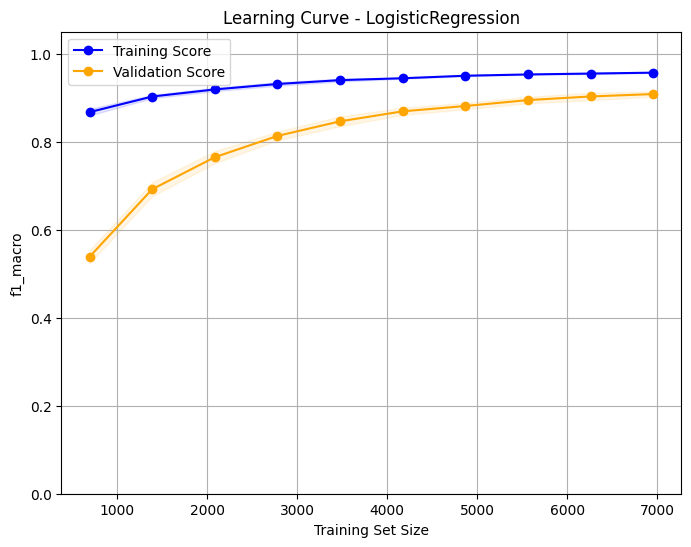


Running model: RidgeClassifier
Params Vectorizer: {'max_features': 7000}


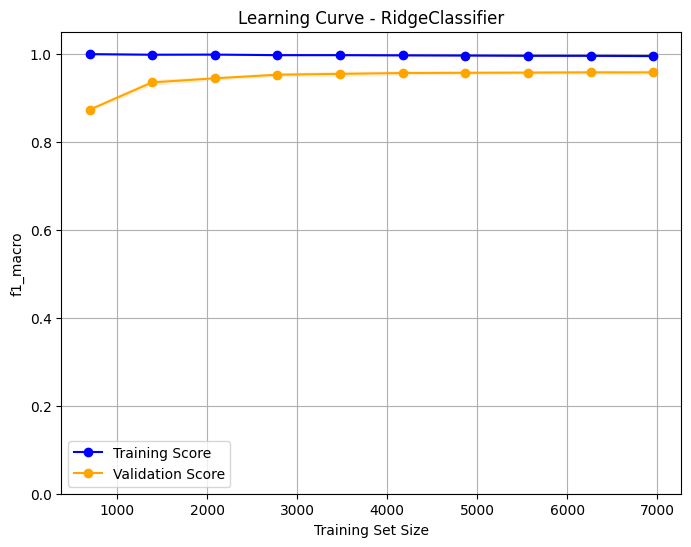


Running model: LinearSVC
Params Vectorizer: {'max_features': 5000}


c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-d

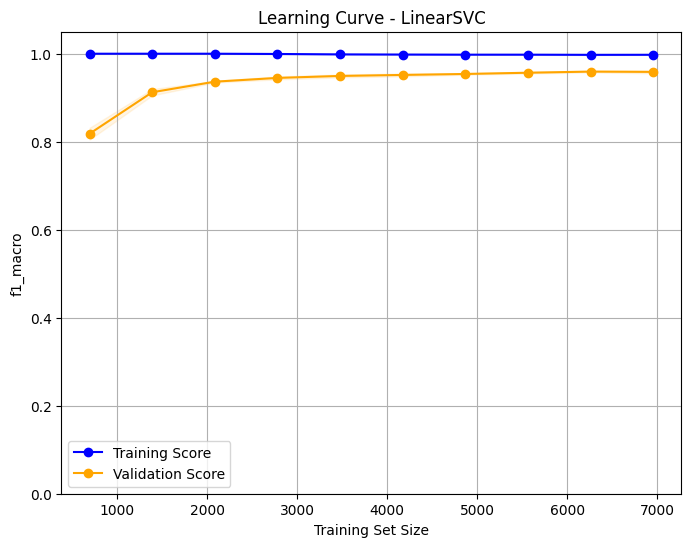


Running model: RandomForest
Params Vectorizer: {'max_features': 6000, 'ngram_range': (1, 2)}


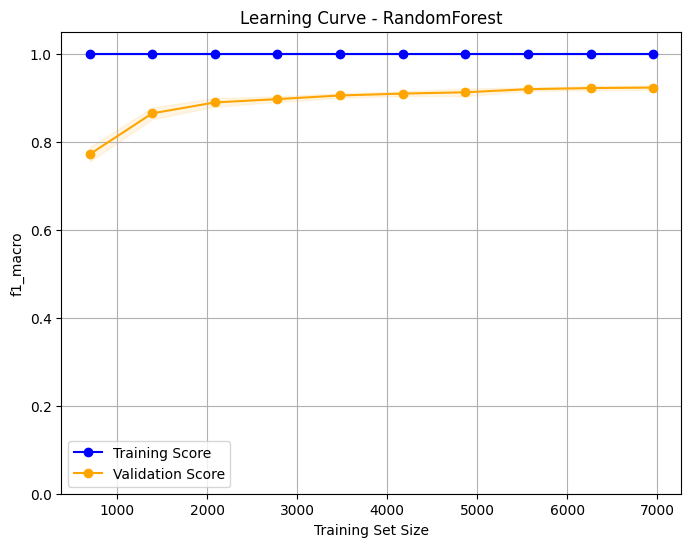


Running model: XGBClassifier
Params Vectorizer: {'max_features': 6000, 'ngram_range': (1, 3)}


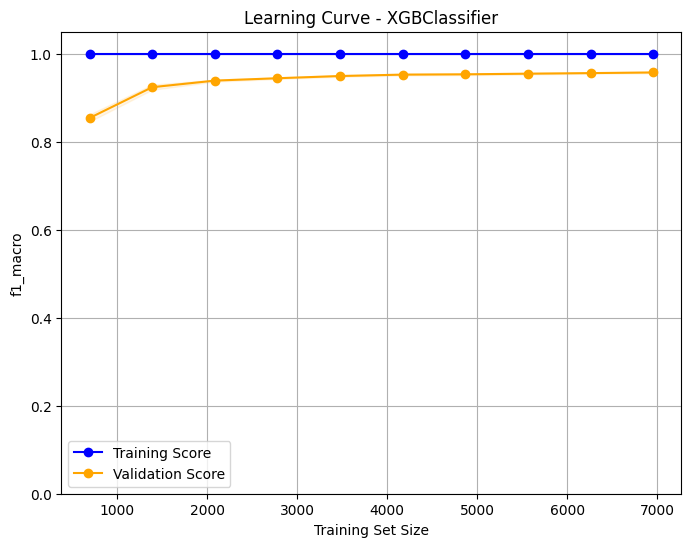

Best model: LinearSVC


In [5]:
best_vect_params = {
    "LogisticRegression":   {"max_features": 2000},
    "RidgeClassifier":      {"max_features": 7000},
    "LinearSVC":            {"max_features": 5000},
    "RandomForest":         {"max_features": 6000, "ngram_range": (1, 2)},
    "XGBClassifier":        {"max_features": 6000, "ngram_range": (1, 3)},
}

models_for_testing = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RidgeClassifier": RidgeClassifier(random_state=42),
    "LinearSVC": OneVsRestClassifier(LinearSVC(random_state=42)),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBClassifier": XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        verbosity=0
    )
}

results = []

def run_predictions(name, model, X_text_train, y_train, vect_params):
    print("\n" + "=" * 80)
    print(f"Running model: {name}")
    print(f"Params Vectorizer: {vect_params}")
    print("=" * 80)

    vectorizer = TfidfVectorizer(**vect_params)

    preprocessor = ColumnTransformer(
        transformers=[
            ('tfidf', vectorizer, text_feature),
            ('scaler', StandardScaler(), numerical_features)
        ],
        remainder='drop'
    )

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    cv_res = avaliar_cv(clone(pipe), X_text_train, y_train, n_splits=5, n_repeats=6)

    plotar_learning_curve(clone(pipe), X_text_train, y_train, model_name=name, cv=5, scoring="f1_macro")

    results.append({
        "Model": name,

        "CV_Accuracy_mean":  cv_res["Accuracy"][0],
        "CV_Accuracy_std":   cv_res["Accuracy"][1],
        "CV_Accuracy_all":   cv_res["Accuracy"][2],

        "CV_Precision_macro_mean":  cv_res["Precision_macro"][0],
        "CV_Precision_macro_std":   cv_res["Precision_macro"][1],
        "CV_Precision_macro_all":   cv_res["Precision_macro"][2],

        "CV_Recall_macro_mean":  cv_res["Recall_macro"][0],
        "CV_Recall_macro_std":   cv_res["Recall_macro"][1],
        "CV_Recall_macro_all":   cv_res["Recall_macro"][2],

        "CV_F1_macro_mean":  cv_res["F1_macro"][0],
        "CV_F1_macro_std":   cv_res["F1_macro"][1],
        "CV_F1_macro_all":   cv_res["F1_macro"][2],
    })

for name, model in models_for_testing.items():
    params = best_vect_params.get(name, {})
    run_predictions(name, model, X_train, y_train, params)

df_results = pd.DataFrame(results)
best_model = df_results.sort_values(by="CV_F1_macro_mean", ascending=False).iloc[0]["Model"]
print("Best model:", best_model)

In [6]:
def format_results(df):
    formatted_df = df.copy()

    for metric in ["Accuracy", "Precision_macro", "Recall_macro", "F1_macro"]:
        mean_col = f"CV_{metric}_mean"
        std_col = f"CV_{metric}_std"

        formatted_df[metric] = (
            formatted_df[mean_col].round(4).astype(str)
            + " ± "
            + formatted_df[std_col].round(4).astype(str)
        )

        # Remove as colunas originais
        formatted_df = formatted_df.drop(columns=[mean_col, std_col])

    # reorganiza colunas
    cols = ["Model", "Accuracy", "Precision_macro", "Recall_macro", "F1_macro"]
    return formatted_df[cols]

df_results.to_csv("../../data/out/feat/feat_03_TweetEmotionsPTBR_TFIDF.csv")
formatted_df = format_results(df_results)
formatted_df.style.hide(axis="index")

Model,Accuracy,Precision_macro,Recall_macro,F1_macro
LogisticRegression,0.9062 ± 0.0072,0.9081 ± 0.0071,0.9067 ± 0.0072,0.9068 ± 0.0071
RidgeClassifier,0.9571 ± 0.0051,0.9585 ± 0.005,0.9576 ± 0.005,0.9577 ± 0.005
LinearSVC,0.9585 ± 0.004,0.9597 ± 0.0039,0.9591 ± 0.004,0.9591 ± 0.004
RandomForest,0.923 ± 0.0062,0.9267 ± 0.006,0.9236 ± 0.0062,0.924 ± 0.0062
XGBClassifier,0.9562 ± 0.0044,0.9584 ± 0.004,0.9569 ± 0.0043,0.9573 ± 0.0042


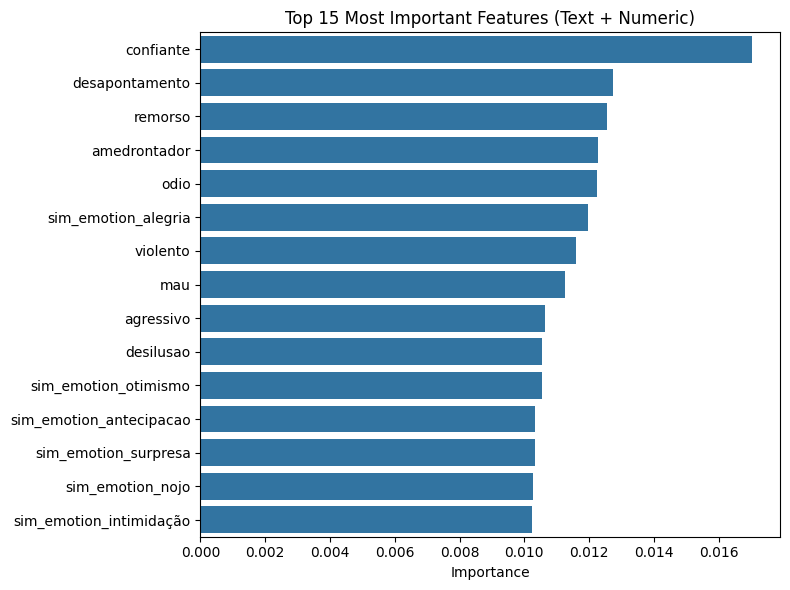

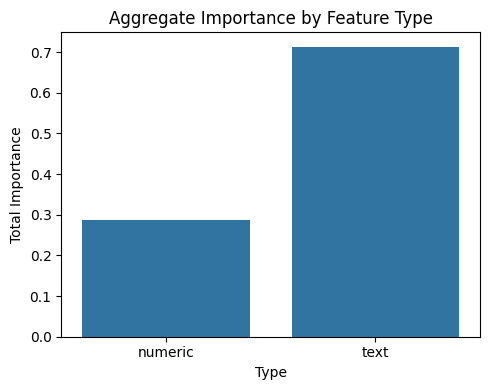

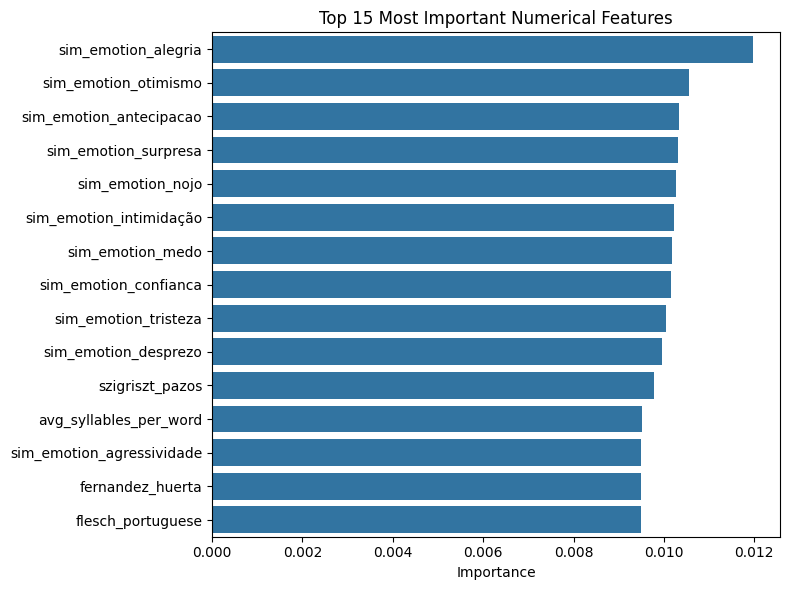

In [7]:
vectorizer = TfidfVectorizer(**{"max_features": 6000, "ngram_range": (1, 2)})

preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', vectorizer, text_feature),
        ('scaler', StandardScaler(), numerical_features)
    ],
    remainder='drop'
)

pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

pipe_rf.fit(X_train, y_train)

preprocessor = pipe_rf.named_steps["preprocessor"]
model = pipe_rf.named_steps["model"]

tfidf = preprocessor.named_transformers_["tfidf"]
tfidf_features = tfidf.get_feature_names_out()

num_features = numerical_features

all_feature_names = np.concatenate([
    tfidf_features,
    num_features
])

importances = model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

top15 = feat_imp.head(15)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=top15,
    x="importance",
    y="feature"
)
plt.title("Top 15 Most Important Features (Text + Numeric)")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

tfidf_set = set(tfidf_features)

feat_imp["type"] = feat_imp["feature"].apply(
    lambda f: "text" if f in tfidf_set else "numeric"
)

agg_imp = (
    feat_imp
    .groupby("type")["importance"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(5, 4))
sns.barplot(
    data=agg_imp,
    x="type",
    y="importance"
)
plt.title("Aggregate Importance by Feature Type")
plt.xlabel("Type")
plt.ylabel("Total Importance")
plt.tight_layout()
plt.show()

num_imp = (
    feat_imp[feat_imp["type"] == "numeric"]
    .sort_values(by="importance", ascending=False)
    .head(15)
)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=num_imp,
    x="importance",
    y="feature"
)
plt.title("Top 15 Most Important Numerical Features")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()